In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Replace these with your actual file paths
filepaths = {
    "A": r"FINAL_models/Model_A/Model_A_Vanilla_r9_loss_data.txt",
    "B": r"FINAL_models/Model_B/Model_B_Ag_r9_loss_data.txt",
    "C": r"FINAL_models/Model_C/Model_C_PCA_r9_loss_data.txt",
    "D": r"FINAL_models/Model_D/Model_D_CNN_r9_loss_data.txt",
}

In [3]:
def load_model_history(filepath):
    """
    Load one training-history text file into a pandas DataFrame.
    Assumes comma-separated values with a header row.
    """
    df = pd.read_csv(filepath)
    
    # Strip any accidental whitespace from column names
    df.columns = [c.strip() for c in df.columns]
    
    # Force numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df


histories = {model_name: load_model_history(fp) for model_name, fp in filepaths.items()}

# Quick check
for name, df in histories.items():
    print(f"{name}: shape = {df.shape}")
    print(df.head(3))
    print()

A: shape = (360, 6)
   epoch  train_loss  val_loss  rollout_raw  rollout_plus_ag_pre_cap  \
0      1    0.039235  0.022029          NaN                      NaN   
1      2    0.024892  0.016227          NaN                      NaN   
2      3    0.019304  0.012088          NaN                      NaN   

   rollout_capped  
0             NaN  
1             NaN  
2             NaN  

B: shape = (360, 6)
   epoch  train_loss  val_loss  rollout_raw  rollout_plus_ag_pre_cap  \
0      1    0.037838  0.020696          NaN                      NaN   
1      2    0.023847  0.015261          NaN                      NaN   
2      3    0.018886  0.011247          NaN                      NaN   

   rollout_capped  
0             NaN  
1             NaN  
2             NaN  

C: shape = (360, 6)
   epoch  train_loss  val_loss  rollout_raw  rollout_plus_ag_pre_cap  \
0      1    0.037940  0.024085          NaN                      NaN   
1      2    0.026135  0.019718          NaN             

In [4]:
# Check that all files have the same epochs and columns
reference_name = list(histories.keys())[0]
reference_df = histories[reference_name]

for name, df in histories.items():
    if not np.array_equal(df["epoch"].values, reference_df["epoch"].values):
        print(f"Epoch mismatch found in model {name}")
    if list(df.columns) != list(reference_df.columns):
        print(f"Column mismatch found in model {name}")

print("Consistency check complete.")
print("Columns:")
print(reference_df.columns.tolist())

Consistency check complete.
Columns:
['epoch', 'train_loss', 'val_loss', 'rollout_raw', 'rollout_plus_ag_pre_cap', 'rollout_capped']


In [5]:
def plot_metric_across_models(
    histories,
    metric,
    figsize=(7, 4.5),
    linewidth=2.0,
    marker=None,
    title=None,
    ylabel=None,
    xlabel="Epoch",
    grid=True,
):
    plt.figure(figsize=figsize)
    
    for model_name, df in histories.items():
        x = df["epoch"].values
        y = df[metric].values
        
        # Matplotlib will automatically break lines at NaNs
        plt.plot(x, y, label=f"Model {model_name}", linewidth=linewidth, marker=marker)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel is not None else metric)
    plt.title(title if title is not None else metric)
    if grid:
        plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

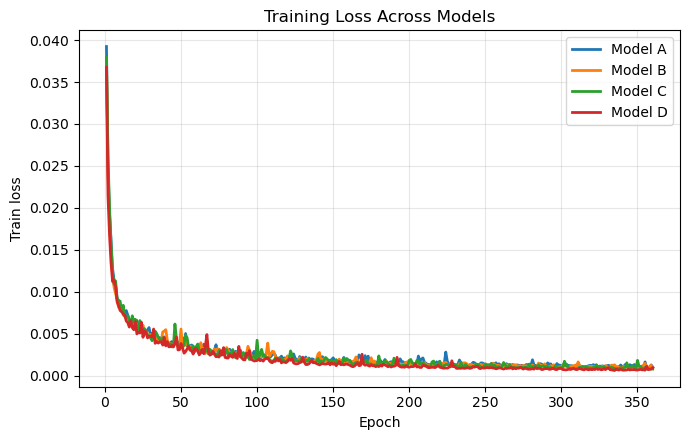

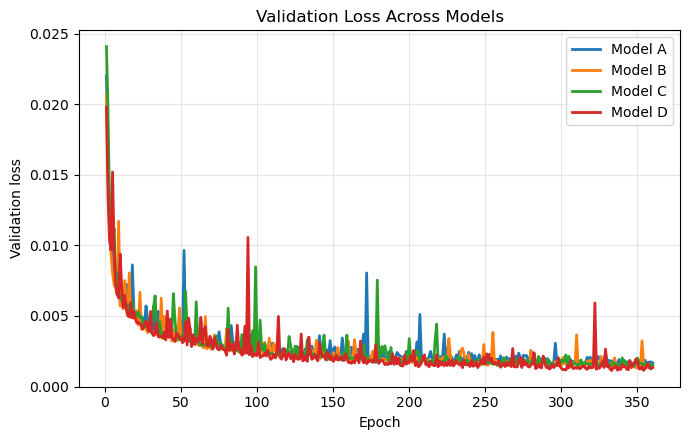

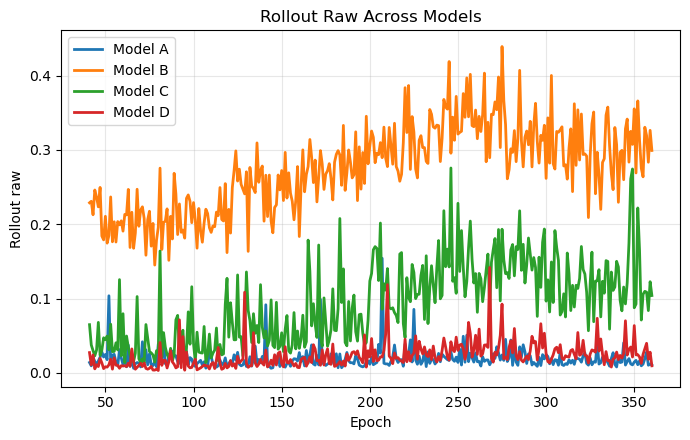

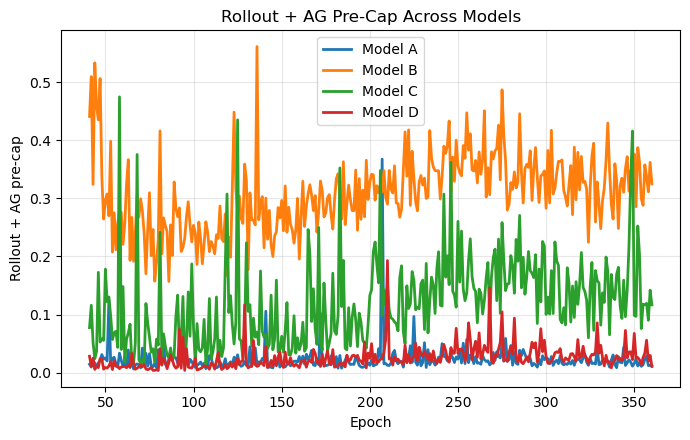

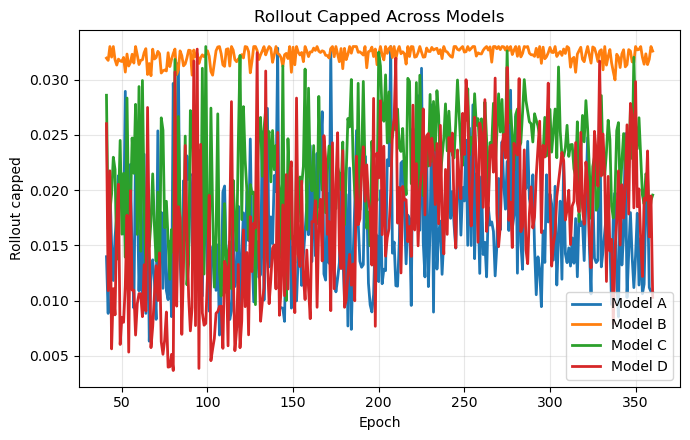

In [9]:
plot_metric_across_models(histories, "train_loss", title="Training Loss Across Models", ylabel="Train loss")
plot_metric_across_models(histories, "val_loss", title="Validation Loss Across Models", ylabel="Validation loss")
plot_metric_across_models(histories, "rollout_raw", title="Rollout Raw Across Models", ylabel="Rollout raw")
plot_metric_across_models(histories, "rollout_plus_ag_pre_cap", title="Rollout + AG Pre-Cap Across Models", ylabel="Rollout + AG pre-cap")
plot_metric_across_models(histories, "rollout_capped", title="Rollout Capped Across Models", ylabel="Rollout capped")

## Compute Ag Contribution

In [10]:
for model_name, df in histories.items():
    df["ag_only_pre_cap"] = df["rollout_plus_ag_pre_cap"] - df["rollout_raw"]

In [11]:
for model_name, df in histories.items():
    print(f"\nModel {model_name}")
    print(df[["epoch", "rollout_raw", "rollout_plus_ag_pre_cap", "ag_only_pre_cap"]].head(10))


Model A
   epoch  rollout_raw  rollout_plus_ag_pre_cap  ag_only_pre_cap
0      1          NaN                      NaN              NaN
1      2          NaN                      NaN              NaN
2      3          NaN                      NaN              NaN
3      4          NaN                      NaN              NaN
4      5          NaN                      NaN              NaN
5      6          NaN                      NaN              NaN
6      7          NaN                      NaN              NaN
7      8          NaN                      NaN              NaN
8      9          NaN                      NaN              NaN
9     10          NaN                      NaN              NaN

Model B
   epoch  rollout_raw  rollout_plus_ag_pre_cap  ag_only_pre_cap
0      1          NaN                      NaN              NaN
1      2          NaN                      NaN              NaN
2      3          NaN                      NaN              NaN
3      4          NaN 

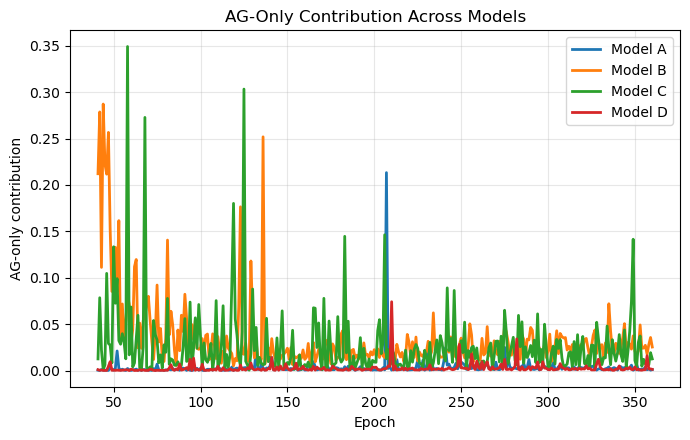

In [12]:
plot_metric_across_models(
    histories,
    metric="ag_only_pre_cap",
    title="AG-Only Contribution Across Models",
    ylabel="AG-only contribution",
)

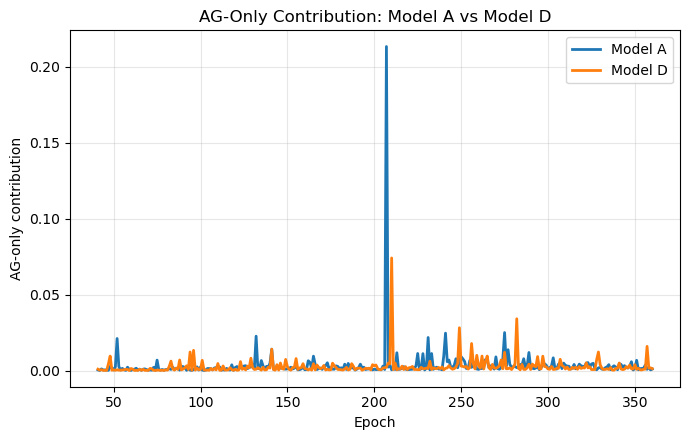

In [13]:
# Plot A and D only for the AG-only contribution

models_to_plot = ["A", "D"]

plt.figure(figsize=(7, 4.5))

for model_name in models_to_plot:
    df = histories[model_name]
    plt.plot(
        df["epoch"],
        df["ag_only_pre_cap"],
        linewidth=2.0,
        label=f"Model {model_name}",
    )

plt.xlabel("Epoch")
plt.ylabel("AG-only contribution")
plt.title("AG-Only Contribution: Model A vs Model D")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Cell 1: imports and a clean publication-style setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Optional: a cleaner default style without seaborn
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.2,
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.25,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

In [18]:
# Cell 2: file paths and loading

# Replace these with your actual file paths
filepaths = {
    "A": r"FINAL_models/Model_A/Model_A_Vanilla_r9_loss_data.txt",
    "B": r"FINAL_models/Model_B/Model_B_Ag_r9_loss_data.txt",
    "C": r"FINAL_models/Model_C/Model_C_PCA_r9_loss_data.txt",
    "D": r"FINAL_models/Model_D/Model_D_CNN_r9_loss_data.txt",
}

def load_model_history(filepath):
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

histories = {name: load_model_history(fp) for name, fp in filepaths.items()}

# Derived metrics
for name, df in histories.items():
    df["ag_only_pre_cap"] = df["rollout_plus_ag_pre_cap"] - df["rollout_raw"]
    df["cap_attenuation"] = df["rollout_plus_ag_pre_cap"] - df["rollout_capped"]

# Quick check
for name, df in histories.items():
    print(name, df.shape, df.columns.tolist())

A (360, 8) ['epoch', 'train_loss', 'val_loss', 'rollout_raw', 'rollout_plus_ag_pre_cap', 'rollout_capped', 'ag_only_pre_cap', 'cap_attenuation']
B (360, 8) ['epoch', 'train_loss', 'val_loss', 'rollout_raw', 'rollout_plus_ag_pre_cap', 'rollout_capped', 'ag_only_pre_cap', 'cap_attenuation']
C (360, 8) ['epoch', 'train_loss', 'val_loss', 'rollout_raw', 'rollout_plus_ag_pre_cap', 'rollout_capped', 'ag_only_pre_cap', 'cap_attenuation']
D (360, 8) ['epoch', 'train_loss', 'val_loss', 'rollout_raw', 'rollout_plus_ag_pre_cap', 'rollout_capped', 'ag_only_pre_cap', 'cap_attenuation']


In [43]:
# Cell 3: helpers for publication-quality plotting

MODEL_COLORS = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green",
    "D": "tab:red",
}

MODEL_LABELS = {
    "A": "Model A",
    "B": "Model B",
    "C": "Model C",
    "D": "Model D",
}

def moving_average_nan(y, window=11):
    """
    NaN-aware moving average.
    Returns an array of same length.
    """
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan, dtype=float)

    if window <= 1:
        return y.copy()

    half = window // 2
    n = len(y)

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        vals = y[lo:hi]
        vals = vals[np.isfinite(vals)]
        if vals.size > 0:
            out[i] = vals.mean()

    return out


def first_valid_epoch_across_models(histories, metric):
    starts = []
    for df in histories.values():
        valid = df[metric].notna()
        if valid.any():
            starts.append(df.loc[valid, "epoch"].iloc[0])
    return min(starts) if len(starts) > 0 else None


def plot_metric_publication(
    histories,
    metric,
    title,
    ylabel,
    figsize=(6.0, 4.5),
    smooth_window=11,
    raw_alpha=0.18,
    smooth_alpha=1.0,
    linewidth_raw=1.0,
    linewidth_smooth=2.4,
    show_raw=True,
    show_smooth=True,
    xlim=None,
    ylim=None,
    valid_region_only=False,
    reference_metric_for_valid="rollout_raw",
    draw_valid_start_line=False,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    start_epoch = None
    if valid_region_only:
        start_epoch = first_valid_epoch_across_models(histories, reference_metric_for_valid)

    for model_name, df in histories.items():
        x = df["epoch"].to_numpy(dtype=float)
        y = df[metric].to_numpy(dtype=float)

        if valid_region_only and start_epoch is not None:
            mask = x >= start_epoch
            x = x[mask]
            y = y[mask]

        color = MODEL_COLORS[model_name]
        label = MODEL_LABELS[model_name]

        if show_raw:
            ax.plot(
                x, y,
                color=color,
                alpha=raw_alpha,
                linewidth=linewidth_raw,
            )

        if show_smooth:
            y_s = moving_average_nan(y, window=smooth_window)
            ax.plot(
                x, y_s,
                color=color,
                alpha=smooth_alpha,
                linewidth=linewidth_smooth,
                label=label,
            )
        elif not show_raw:
            ax.plot(
                x, y,
                color=color,
                linewidth=linewidth_smooth,
                label=label,
            )

    if draw_valid_start_line and start_epoch is not None:
        ax.axvline(start_epoch, linestyle="--", linewidth=1.5, alpha=0.7, color="k")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    #ax.legend(frameon=True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

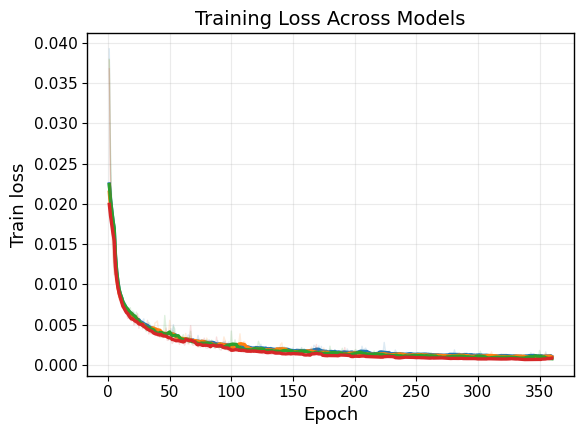

In [44]:
# Cell 4: Train loss

plot_metric_publication(
    histories=histories,
    metric="train_loss",
    title="Training Loss Across Models",
    ylabel="Train loss",
    smooth_window=9,
    raw_alpha=0.15,
    save_path="fig_train_loss.png",
)

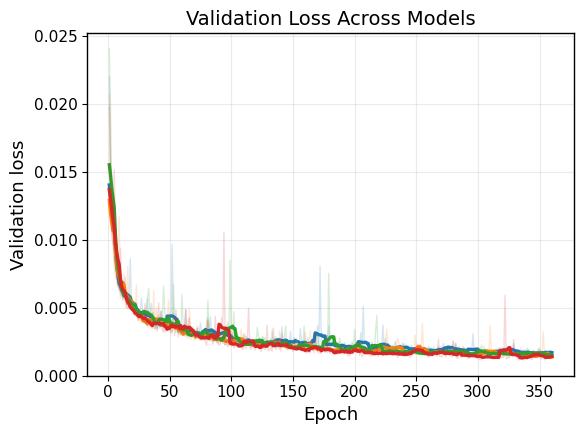

In [29]:
# Cell 5: Validation loss

plot_metric_publication(
    histories=histories,
    metric="val_loss",
    title="Validation Loss Across Models",
    ylabel="Validation loss",
    smooth_window=9,
    raw_alpha=0.18,
    save_path="fig_val_loss.png",
)

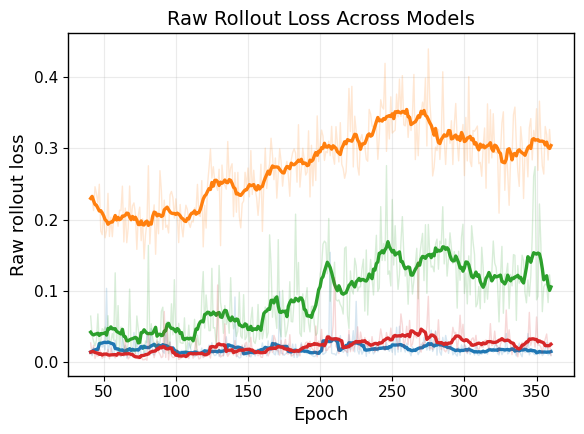

In [30]:
# Cell 6: Raw rollout loss

plot_metric_publication(
    histories=histories,
    metric="rollout_raw",
    title="Raw Rollout Loss Across Models",
    ylabel="Raw rollout loss",
    smooth_window=11,
    raw_alpha=0.18,
    valid_region_only=True,
    draw_valid_start_line=False,
    save_path="fig_rollout_raw.png",
)

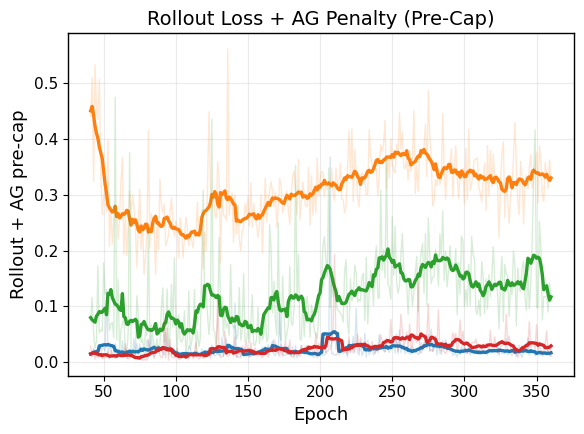

In [31]:
# Cell 7: Rollout + AG pre-cap

plot_metric_publication(
    histories=histories,
    metric="rollout_plus_ag_pre_cap",
    title="Rollout Loss + AG Penalty (Pre-Cap)",
    ylabel="Rollout + AG pre-cap",
    smooth_window=11,
    raw_alpha=0.18,
    valid_region_only=True,
    draw_valid_start_line=False,
    save_path="fig_rollout_pre_cap.png",
)

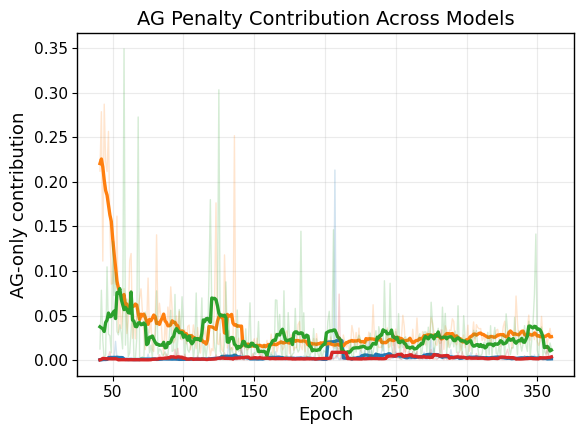

In [32]:
# Cell 8: AG-only contribution

plot_metric_publication(
    histories=histories,
    metric="ag_only_pre_cap",
    title="AG Penalty Contribution Across Models",
    ylabel="AG-only contribution",
    smooth_window=11,
    raw_alpha=0.20,
    valid_region_only=True,
    draw_valid_start_line=False,
    save_path="fig_ag_only.png",
)

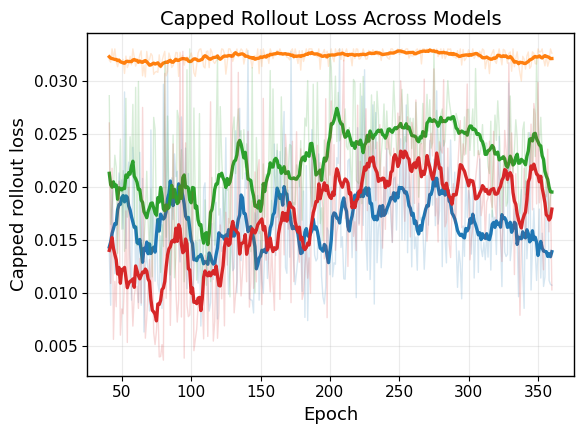

In [33]:
# Cell 9: Post-cap rollout loss

plot_metric_publication(
    histories=histories,
    metric="rollout_capped",
    title="Capped Rollout Loss Across Models",
    ylabel="Capped rollout loss",
    smooth_window=11,
    raw_alpha=0.18,
    valid_region_only=True,
    draw_valid_start_line=False,
    save_path="fig_rollout_capped.png",
)

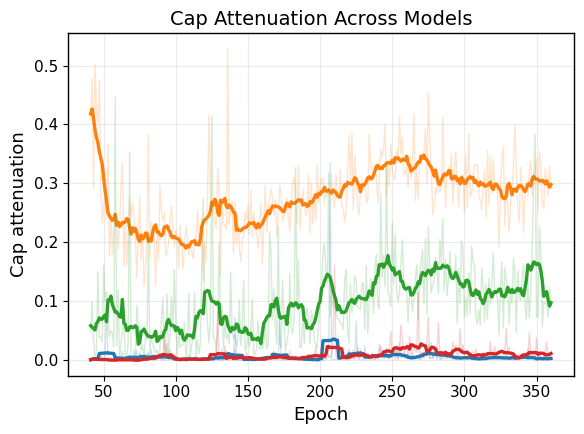

In [34]:
# Cell 10: Optional sixth alternative instead of capped rollout:
# Cap attenuation = (pre-cap) - (capped)
# Use this if you decide it is more interpretable for the paper.

plot_metric_publication(
    histories=histories,
    metric="cap_attenuation",
    title="Cap Attenuation Across Models",
    ylabel="Cap attenuation",
    smooth_window=11,
    raw_alpha=0.20,
    valid_region_only=True,
    draw_valid_start_line=False,
    save_path="fig_cap_attenuation.png",
)

In [39]:
def plot_metric_publication(
    histories,
    metric,
    title,
    ylabel,
    figsize=(6.0, 4.5),
    smooth_window=11,
    raw_alpha=0.18,
    smooth_alpha=1.0,
    linewidth_raw=1.0,
    linewidth_smooth=2.4,
    show_raw=True,
    show_smooth=True,
    xlim=None,
    ylim=None,
    valid_region_only=False,
    reference_metric_for_valid="rollout_raw",
    draw_valid_start_line=False,
    hline_y=None,
    hline_label=None,
    hline_kwargs=None,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    start_epoch = None
    if valid_region_only:
        start_epoch = first_valid_epoch_across_models(histories, reference_metric_for_valid)

    for model_name, df in histories.items():
        x = df["epoch"].to_numpy(dtype=float)
        y = df[metric].to_numpy(dtype=float)

        if valid_region_only and start_epoch is not None:
            mask = x >= start_epoch
            x = x[mask]
            y = y[mask]

        color = MODEL_COLORS[model_name]
        label = MODEL_LABELS[model_name]

        if show_raw:
            ax.plot(
                x, y,
                color=color,
                alpha=raw_alpha,
                linewidth=linewidth_raw,
            )

        if show_smooth:
            y_s = moving_average_nan(y, window=smooth_window)
            ax.plot(
                x, y_s,
                color=color,
                alpha=smooth_alpha,
                linewidth=linewidth_smooth,
                label=label,
            )
        elif not show_raw:
            ax.plot(
                x, y,
                color=color,
                linewidth=linewidth_smooth,
                label=label,
            )

    if draw_valid_start_line and start_epoch is not None:
        ax.axvline(start_epoch, linestyle="--", linewidth=1.5, alpha=0.7, color="k")

    if hline_y is not None:
        hk = dict(linestyle="--", linewidth=1.8, color="k", alpha=0.9)
        if hline_kwargs is not None:
            hk.update(hline_kwargs)
        ax.axhline(hline_y, label=hline_label, **hk)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    #ax.legend(frameon=True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

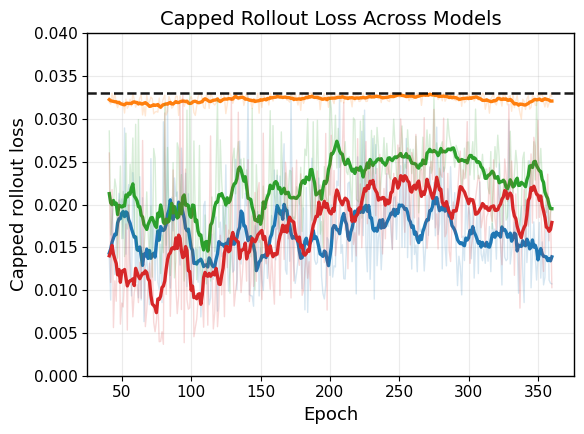

In [40]:
plot_metric_publication(
    histories=histories,
    metric="rollout_capped",
    title="Capped Rollout Loss Across Models",
    ylabel="Capped rollout loss",
    smooth_window=11,
    raw_alpha=0.18,
    valid_region_only=True,
    draw_valid_start_line=False,
    ylim=(0.0, 0.04),
    hline_y=0.033,
    hline_label="Cap = 0.033",
    save_path="fig_rollout_capped_with_capline.png",
)